## **Binary Logistic Regression**

### **Project:**

- Email Spam Detection

### **Problem Statement:**

- Classify emails as spam or not spam using message content.

In [18]:
# Step No : 1 Importing required Libraries 

# Numerical operations 
import numpy as np 

# Data manipulation and analysis
import pandas as pd 

# Data visualization 
import matplotlib.pyplot as plt 

# Advanced visualization
import seaborn as sns

# Machine Learning
# Split data into training and testing sets 
from sklearn.model_selection import train_test_split

# Text to numeric conversion
from sklearn.feature_extraction.text import CountVectorizer 

# Logistic Regression model
from sklearn.linear_model import LogisticRegression

# Evaluation metrics
from sklearn.metrics import classification_report , accuracy_score , confusion_matrix

In [19]:
# Step 2 : Loading the dataset 
df = pd.read_csv("spam.csv" , encoding = "latin-1")

In [20]:
# Step 3 : Understanding the dataset 

# Display first 5 rows of the dataset 
print(df.head())

# Display the shape of the dataset 
print(df.shape)

# Display the info of the dataset 
print(df.info())

     v1  ... Unnamed: 4
0   ham  ...        NaN
1   ham  ...        NaN
2  spam  ...        NaN
3   ham  ...        NaN
4   ham  ...        NaN

[5 rows x 5 columns]
(5572, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB
None


In [21]:
# Step 4 : Data Preprocessing and Cleaning 

# Keep only hte required columns 
df = df[["v1" , "v2"]]

# Rename the columns 
df = df.rename(columns = {
    "v1": "Spam",
    "v2": "Message"
})

# Display missing values 
print(df.isnull().sum())

# Display duplicate values 
print(df.duplicated().sum())

# Remove duplicate values 
df = df.drop_duplicates()

Spam       0
Message    0
dtype: int64
403


In [22]:
# Step 5 : Encoding Target Variable 

# Convert spam and ham to 1 and 0 respectively 
df["Spam"] = df["Spam"].map({
    "ham": 0,
    "spam": 1
})

In [23]:
# Step 6 : Feature and Target Splitting 

# Define input feature
X = df["Message"]

# Define target variable 
y = df["Spam"]



In [24]:
# Step 7 : Text Vectorization

# Create CountVectorizer object 
vectorizer = CountVectorizer()

# convert text data to numeric data 
X = vectorizer.fit_transform(X)

In [25]:
# Step 8 : Train Test Split for Model Evaluation

# Split dataset into training and testing sets 
X_train , X_test , y_train , y_test = train_test_split(X,
                                                       y,
                                                       test_size = 0.2,
                                                       random_state = 42)

In [26]:
# Step 9 : Initialize and Logistic Regression Model

# Create Logistic Regression model object 
model = LogisticRegression()


In [27]:
# Step 10 : Model Training 

# Train Model 
model.fit(X_train , y_train)

LogisticRegression()

In [28]:
# Step 11 : Model Prediction
y_pred = model.predict(X_test)

# Display prediction values
print("Predicted Values : ")
print(y_pred)

Predicted Values : 
[0 0 0 ... 1 0 0]


In [29]:
# Model Evaluation 

# Calculate accuracy score 
print("Accuracy Score : ")
print(accuracy_score(y_test , y_pred))

# Display classification report 
print("Classification Report : ")
print(classification_report(y_test , y_pred))

# Display confusion matrix 
print("Confusion Matrix : ")
print(confusion_matrix(y_test , y_pred))

Accuracy Score : 
0.9787234042553191
Classification Report : 
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       889
           1       0.97      0.88      0.92       145

    accuracy                           0.98      1034
   macro avg       0.97      0.94      0.95      1034
weighted avg       0.98      0.98      0.98      1034

Confusion Matrix : 
[[885   4]
 [ 18 127]]


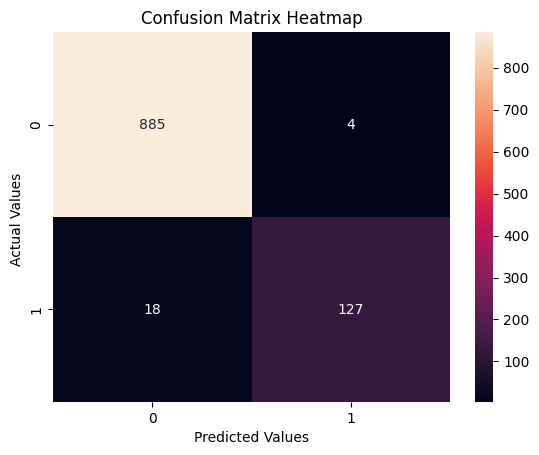

In [30]:
# Step No 13 : Visualization of Confusion Matrix 

# Create heatmap for confusion matrix 
sns.heatmap(
    confusion_matrix(y_test , y_pred),
    annot = True,
    fmt = "d"
)

# Set plot title 
plt.title("Confusion Matrix Heatmap")

# Set x- axis label
plt.xlabel("Predicted Values")

# Set y- axis label
plt.ylabel("Actual Values ")

# Save figure 
plt.savefig("confusion_matrix_heatmap(Binary Logistic Regression).png")

# Display plot 
plt.show()

In [31]:
# Step No 14 : User Input 

# Take massage input 
message = input("Enter Email Message : ")


In [32]:
# Step 15 : Prediction on User Input 

# convert user message into vector
message_vector = vectorizer.transform([message])

# Predict result for user input 
result = model.predict(message_vector)

In [33]:
# Step 16 : Final Output 
# Display final output 
if result[0] == 1 :
    print("This Email is Spam.")
else:
    print("This Email is Not Spam.")

This Email is Not Spam.
